In [2]:
!pip install cupy-cuda12x opencv-python matplotlib


Run CPU:
CPU Time: 0.891 ms

Run GPU:
GPU Time: 1.929045 ms
Speedup GPU vs CPU: 0.46174762081324927


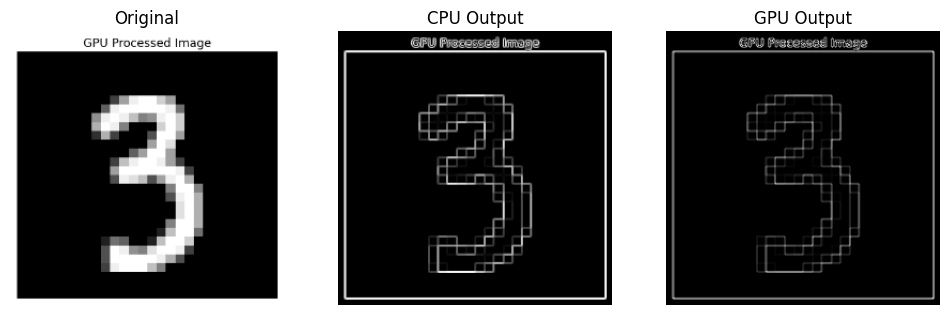

In [13]:
import cupy as cp
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
img = cv2.imread("digit3.png",0)

img = cv2.resize(img,(256,256))
print("\nRun CPU:")

start_cpu = time.time()

sobelx = cv2.Sobel(img, cv2.CV_64F,1,0,ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F,0,1,ksize=3)

cpu_edges = cv2.magnitude(sobelx,sobely)

cpu_time = (time.time() - start_cpu)*1000

print("CPU Time:",round(cpu_time,3),"ms")
print("\nRun GPU:")

start_gpu = time.time()

gpu_img = cp.asarray(img)

gx = cp.abs(cp.gradient(gpu_img.astype(cp.float32),axis=0))
gy = cp.abs(cp.gradient(gpu_img.astype(cp.float32),axis=1))

gpu_edges = gx + gy

gpu_edges_cpu = cp.asnumpy(gpu_edges)

gpu_time = (time.time() - start_gpu)*1000

print("GPU Time:",round(gpu_time,6),"ms")

print("Speedup GPU vs CPU:",cpu_time/gpu_time)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img,cmap="gray")
plt.axis("off")
plt.subplot(1,3,2)
plt.title("CPU Output")
plt.imshow(cpu_edges,cmap="gray")
plt.axis("off")
plt.subplot(1,3,3)
plt.title("GPU Output")
plt.imshow(gpu_edges_cpu,cmap="gray")
plt.axis("off")
plt.show()